# Model Evaluation — fastMRI Prostate Cancer Classification
**Models:** ConvNeXt-Small, ConvNeXt-Small + MIL Attention, EfficientNet-B3  
**Task:** Binary classification — PIRADS ≥ 3 = clinically significant prostate cancer  
**Author:** Akshaya Ganesh

In [1]:
# Cell 1 — Mount Drive and extract DICOMs
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import tarfile

DATA_DIR  = '/content/drive/MyDrive/Colab Notebooks'
DICOM_DIR = '/content/DICOMS'
os.makedirs(DICOM_DIR, exist_ok=True)

print('Extracting DICOMs...')
with tarfile.open(f'{DATA_DIR}/fastmri_prostate_DICOMS_IDS_001_312.tar', 'r') as tar:
    tar.extractall(DICOM_DIR)

DICOM_DIR = '/content/DICOMS/DICOMS'
print(f'Patients: {len(os.listdir(DICOM_DIR))}')

Mounted at /content/drive
Extracting DICOMs...


/tmp/ipykernel_7983/2693115195.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DICOM_DIR)


Patients: 312


In [2]:
# Cell 2 — Installs
!pip install pydicom -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.1 MB/s eta 0:00:00


In [3]:
# Cell 3 — Imports
import os
import json
import numpy as np
import pandas as pd
import tarfile
import pydicom
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, precision_recall_curve, average_precision_score
)
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [4]:
# Cell 4 — Load labels and create test split
labels_tar = f'{DATA_DIR}/labels.tar'
with tarfile.open(labels_tar, 'r') as tar:
    f = tar.extractfile('labels/t2_slice_level_labels.csv')
    t2_labels = pd.read_csv(f)
    f = tar.extractfile('labels/volume_exam_labels.csv')
    volume_labels = pd.read_csv(f)

volume_labels['binary_label'] = (volume_labels['t2_volume_level'] >= 3).astype(int)
patient_split = t2_labels.drop_duplicates('fastmri_pt_id')[['fastmri_pt_id', 'data_split']]
df = patient_split.merge(
    volume_labels[['fastmri_pt_id', 'binary_label', 't2_volume_level']],
    on='fastmri_pt_id'
)

invalid_ids = [115, 258]
test_df = df[df['data_split'] == 'test'].reset_index(drop=True)
test_df = test_df[~test_df['fastmri_pt_id'].isin(invalid_ids)].reset_index(drop=True)

# Also keep train_df for pos_weight calculation
train_df = df[df['data_split'] == 'training'].reset_index(drop=True)
train_df = train_df[~train_df['fastmri_pt_id'].isin(invalid_ids)].reset_index(drop=True)

print(f'Test patients: {len(test_df)}')
print(f'Test labels: {test_df.binary_label.value_counts().to_dict()}')

Test patients: 46
Test labels: {0: 26, 1: 20}


In [5]:
# Cell 5 — Dataset classes
NUM_SLICES = 30

# 3x3 grid dataset (used by ConvNeXt and EfficientNet)
class ProstateT2Dataset(Dataset):
    def __init__(self, df, dicom_dir):
        self.df = df.reset_index(drop=True)
        self.dicom_dir = dicom_dir
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pt_id   = str(row.fastmri_pt_id).zfill(3)
        t2_path = os.path.join(self.dicom_dir, pt_id, 'AX_T2')
        slices  = []
        for fname in os.listdir(t2_path):
            if fname.endswith('.dcm'):
                ds = pydicom.dcmread(os.path.join(t2_path, fname))
                slices.append((int(ds.InstanceNumber), ds.pixel_array.astype(np.float32)))
        slices.sort(key=lambda x: x[0])
        volume = np.stack([s[1] for s in slices])
        volume = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)
        mid      = volume.shape[0] // 2
        selected = volume[mid-4:mid+5]
        rows = []
        for i in range(3):
            row_img = np.concatenate([selected[i*3], selected[i*3+1], selected[i*3+2]], axis=1)
            rows.append(row_img)
        grid = np.concatenate(rows, axis=0)
        img  = Image.fromarray((grid * 255).astype(np.uint8)).convert('RGB')
        img  = self.transform(img)
        label = torch.tensor(row.binary_label, dtype=torch.float32)
        return img, label


# MIL dataset (used by MIL model)
class ProstateT2MILDataset(Dataset):
    def __init__(self, df, dicom_dir):
        self.df = df.reset_index(drop=True)
        self.dicom_dir = dicom_dir
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        pt_id  = str(row.fastmri_pt_id).zfill(3)
        t2_path = os.path.join(self.dicom_dir, pt_id, 'AX_T2')
        slices = []
        for fname in os.listdir(t2_path):
            if fname.endswith('.dcm'):
                ds = pydicom.dcmread(os.path.join(t2_path, fname))
                slices.append((int(ds.InstanceNumber), ds.pixel_array.astype(np.float32)))
        slices.sort(key=lambda x: x[0])
        volume = np.stack([s[1] for s in slices])
        volume = (volume - volume.min()) / (volume.max() - volume.min() + 1e-8)
        n   = volume.shape[0]
        mid = n // 2
        start = max(0, mid - NUM_SLICES // 2)
        end   = min(n, start + NUM_SLICES)
        volume = volume[start:end]
        if volume.shape[0] < NUM_SLICES:
            pad    = np.zeros((NUM_SLICES - volume.shape[0], volume.shape[1], volume.shape[2]))
            volume = np.concatenate([volume, pad], axis=0)
        slice_tensors = []
        for s in volume:
            img = Image.fromarray((s * 255).astype(np.uint8)).convert('RGB')
            slice_tensors.append(self.transform(img))
        volume_tensor = torch.stack(slice_tensors)
        label = torch.tensor(row.binary_label, dtype=torch.float32)
        return volume_tensor, label

In [6]:
# Cell 6 — Model architectures

# ConvNeXt-Small
def get_convnext(dropout=0.5):
    model = models.convnext_small(weights=None)
    for i, layer in enumerate(model.features):
        if i < 4:
            for param in layer.parameters():
                param.requires_grad = False
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 1)
    )
    return model


# EfficientNet-B3
def get_efficientnet(dropout=0.5):
    model = models.efficientnet_b3(weights=None)
    for i, block in enumerate(model.features):
        if i < 4:
            for param in block.parameters():
                param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, 1)
    )
    return model


# MIL model
class AttentionMIL(nn.Module):
    def __init__(self, feature_dim=768):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(feature_dim, 128), nn.Tanh(), nn.Linear(128, 1)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(feature_dim, 1)
        )

    def forward(self, x):
        attn = torch.softmax(self.attention(x), dim=1)
        x    = (attn * x).sum(dim=1)
        return self.classifier(x)


class ConvNeXtMIL(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.convnext_small(weights=None)
        for i, layer in enumerate(backbone.features):
            if i < 4:
                for param in layer.parameters():
                    param.requires_grad = False
        self.feature_extractor = nn.Sequential(backbone.features, backbone.avgpool)
        self.mil = AttentionMIL(feature_dim=768)

    def forward(self, x):
        batch, num_slices, C, H, W = x.shape
        x        = x.view(batch * num_slices, C, H, W)
        features = self.feature_extractor(x)
        features = features.view(batch, num_slices, -1)
        return self.mil(features)


print('Model architectures defined.')

Model architectures defined.


In [7]:
# Cell 7 — Load saved results JSON files
results = {}

for name, path in [
    ('ConvNeXt',     f'{DATA_DIR}/convnext_results.json'),
    ('MIL',          f'{DATA_DIR}/mil_results.json'),
    ('EfficientNet', f'{DATA_DIR}/efficientnet_results.json'),
]:
    if os.path.exists(path):
        with open(path) as f:
            results[name] = json.load(f)
        print(f'{name}: Val AUC={results[name]["best_val_auc"]:.4f}, Test AUC={results[name]["test_auc"]:.4f}')
    else:
        print(f'{name}: results file not found at {path}')

ConvNeXt: Val AUC=0.5303, Test AUC=0.4808
MIL: Val AUC=0.6154, Test AUC=0.4115
EfficientNet: Val AUC=0.6813, Test AUC=0.5500


In [8]:
# Cell 8 — Load models and get predictions on test set
def get_predictions(model, loader, device):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            output = torch.sigmoid(model(imgs).squeeze(1))
            preds  = (output > 0.5).float()
            all_probs.extend(output.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_probs), np.array(all_preds), np.array(all_labels)


# Test datasets and loaders
test_dataset_grid = ProstateT2Dataset(test_df, DICOM_DIR)
test_dataset_mil  = ProstateT2MILDataset(test_df, DICOM_DIR)

test_loader_grid = DataLoader(test_dataset_grid, batch_size=16, shuffle=False, num_workers=0)
test_loader_mil  = DataLoader(test_dataset_mil,  batch_size=4,  shuffle=False, num_workers=0)

model_predictions = {}

# ── ConvNeXt ──────────────────────────────────────────────────────────────
convnext_dropout = results['ConvNeXt']['best_params']['dropout'] if 'ConvNeXt' in results else 0.5
convnext_path    = f'{DATA_DIR}/best_convnext_final.pth'
# If k-fold was used, pick the best fold
if not os.path.exists(convnext_path):
    best_fold = np.argmax([results['ConvNeXt'].get(f'fold_{i}_val_auc', 0) for i in range(1, 6)]) + 1
    convnext_path = f'{DATA_DIR}/best_fold_{best_fold}.pth'

if os.path.exists(convnext_path):
    convnext_model = get_convnext(dropout=convnext_dropout).to(device)
    convnext_model.load_state_dict(torch.load(convnext_path, map_location=device))
    probs, preds, labels = get_predictions(convnext_model, test_loader_grid, device)
    model_predictions['ConvNeXt-Small'] = {'probs': probs, 'preds': preds, 'labels': labels}
    print(f'ConvNeXt loaded. Test AUC: {roc_auc_score(labels, probs):.4f}')
else:
    print(f'ConvNeXt weights not found at {convnext_path}')

# ── MIL ───────────────────────────────────────────────────────────────────
mil_path = f'{DATA_DIR}/best_mil_model.pth'
if os.path.exists(mil_path):
    mil_model = ConvNeXtMIL().to(device)
    mil_model.load_state_dict(torch.load(mil_path, map_location=device))
    probs, preds, labels = get_predictions(mil_model, test_loader_mil, device)
    model_predictions['ConvNeXt+MIL'] = {'probs': probs, 'preds': preds, 'labels': labels}
    print(f'MIL loaded. Test AUC: {roc_auc_score(labels, probs):.4f}')
else:
    print(f'MIL weights not found at {mil_path}')

# ── EfficientNet ──────────────────────────────────────────────────────────
eff_dropout = results['EfficientNet']['best_params']['dropout'] if 'EfficientNet' in results else 0.5
eff_path    = f'{DATA_DIR}/best_efficientnet.pth'
if os.path.exists(eff_path):
    eff_model = get_efficientnet(dropout=eff_dropout).to(device)
    eff_model.load_state_dict(torch.load(eff_path, map_location=device))
    probs, preds, labels = get_predictions(eff_model, test_loader_grid, device)
    model_predictions['EfficientNet-B3'] = {'probs': probs, 'preds': preds, 'labels': labels}
    print(f'EfficientNet loaded. Test AUC: {roc_auc_score(labels, probs):.4f}')
else:
    print(f'EfficientNet weights not found at {eff_path}')

ConvNeXt loaded. Test AUC: 0.4808
MIL loaded. Test AUC: 0.4115
EfficientNet loaded. Test AUC: 0.5500


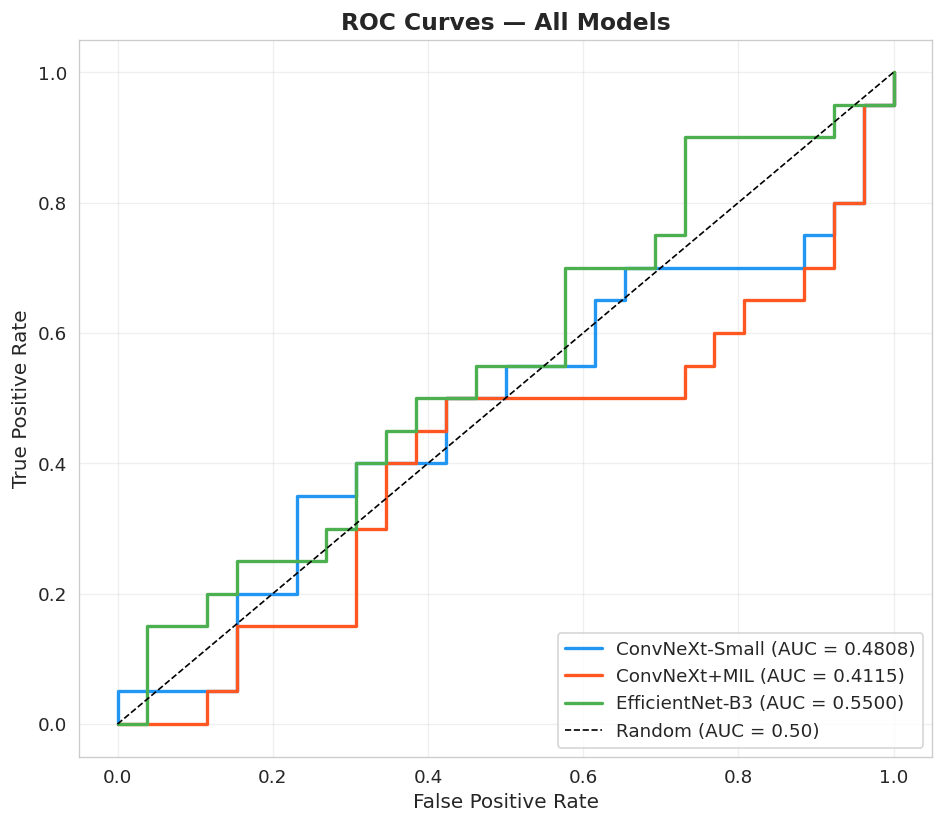

In [9]:
# Cell 9 — ROC curves (all models on same plot)
colors = ['#2196F3', '#FF5722', '#4CAF50']

plt.figure(figsize=(8, 7))
for (name, data), color in zip(model_predictions.items(), colors):
    fpr, tpr, _ = roc_curve(data['labels'], data['probs'])
    auc = roc_auc_score(data['labels'], data['probs'])
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eval_roc_curves.png', bbox_inches='tight')
plt.show()

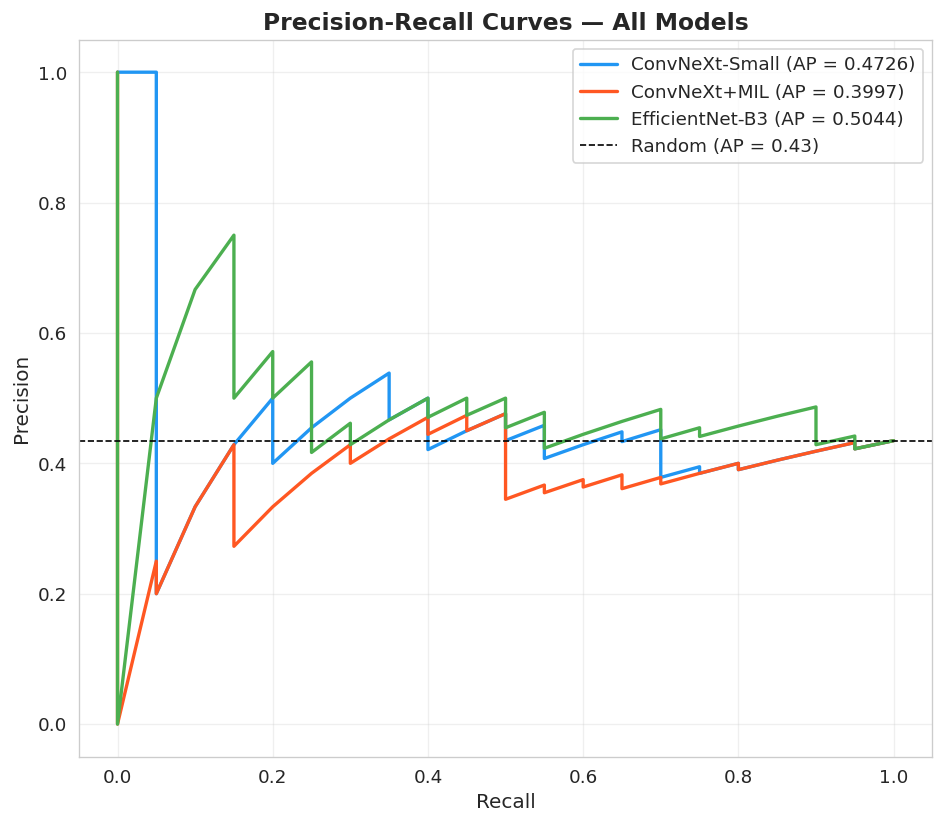

In [10]:
# Cell 10 — Precision-Recall curves
plt.figure(figsize=(8, 7))
for (name, data), color in zip(model_predictions.items(), colors):
    precision, recall, _ = precision_recall_curve(data['labels'], data['probs'])
    ap = average_precision_score(data['labels'], data['probs'])
    plt.plot(recall, precision, color=color, linewidth=2, label=f'{name} (AP = {ap:.4f})')

# Baseline (random)
baseline = data['labels'].mean()
plt.axhline(y=baseline, color='k', linestyle='--', linewidth=1, label=f'Random (AP = {baseline:.2f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eval_pr_curves.png', bbox_inches='tight')
plt.show()

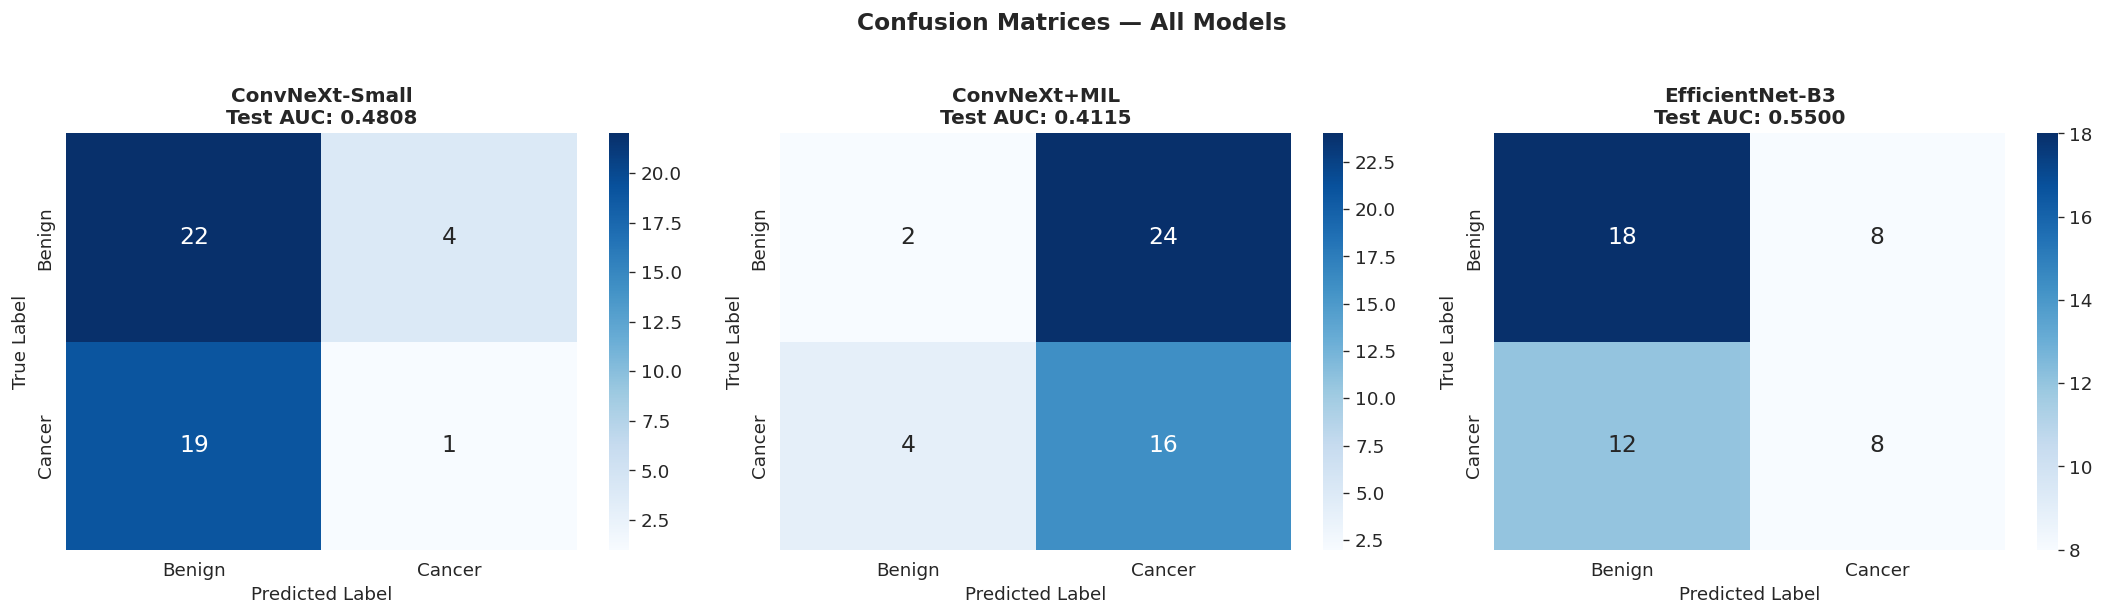

In [11]:
# Cell 11 — Confusion matrices
n_models = len(model_predictions)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, data) in zip(axes, model_predictions.items()):
    cm = confusion_matrix(data['labels'], data['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Cancer'],
                yticklabels=['Benign', 'Cancer'],
                annot_kws={'size': 14})
    auc = roc_auc_score(data['labels'], data['probs'])
    ax.set_title(f'{name}\nTest AUC: {auc:.4f}', fontweight='bold', fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eval_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [12]:
# Cell 12 — Classification reports
print('=' * 60)
for name, data in model_predictions.items():
    print(f'\n{"=" * 60}')
    print(f'  {name}')
    print(f'{"=" * 60}')
    print(classification_report(
        data['labels'], data['preds'],
        target_names=['Benign (PIRADS 1-2)', 'Cancer (PIRADS 3-5)'],
        digits=4
    ))
    auc = roc_auc_score(data['labels'], data['probs'])
    ap  = average_precision_score(data['labels'], data['probs'])
    print(f'  ROC AUC:           {auc:.4f}')
    print(f'  Average Precision: {ap:.4f}')


  ConvNeXt-Small
                     precision    recall  f1-score   support

Benign (PIRADS 1-2)     0.5366    0.8462    0.6567        26
Cancer (PIRADS 3-5)     0.2000    0.0500    0.0800        20

           accuracy                         0.5000        46
          macro avg     0.3683    0.4481    0.3684        46
       weighted avg     0.3902    0.5000    0.4060        46

  ROC AUC:           0.4808
  Average Precision: 0.4726

  ConvNeXt+MIL
                     precision    recall  f1-score   support

Benign (PIRADS 1-2)     0.3333    0.0769    0.1250        26
Cancer (PIRADS 3-5)     0.4000    0.8000    0.5333        20

           accuracy                         0.3913        46
          macro avg     0.3667    0.4385    0.3292        46
       weighted avg     0.3623    0.3913    0.3025        46

  ROC AUC:           0.4115
  Average Precision: 0.3997

  EfficientNet-B3
                     precision    recall  f1-score   support

Benign (PIRADS 1-2)     0.6000    0

In [13]:
# Cell 13 — Summary comparison table
summary_rows = []
for name, data in model_predictions.items():
    cm   = confusion_matrix(data['labels'], data['preds'])
    tn, fp, fn, tp = cm.ravel()
    auc  = roc_auc_score(data['labels'], data['probs'])
    ap   = average_precision_score(data['labels'], data['probs'])
    sens = tp / (tp + fn)  # recall for cancer class
    spec = tn / (tn + fp)  # recall for benign class
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0  # precision for cancer
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0  # precision for benign
    acc  = (tp + tn) / (tp + tn + fp + fn)

    # Get val AUC from results if available
    model_key = name.replace('-Small', '').replace('-B3', '').replace('+MIL', '').replace('ConvNeXt', 'ConvNeXt').replace('EfficientNet', 'EfficientNet')
    val_auc = results.get(name.split('+')[0].strip().replace(' ', ''), {}).get('best_val_auc', 'N/A')

    summary_rows.append({
        'Model':          name,
        'Test AUC':       round(auc, 4),
        'Avg Precision':  round(ap, 4),
        'Accuracy':       round(acc, 4),
        'Sensitivity':    round(sens, 4),
        'Specificity':    round(spec, 4),
        'PPV':            round(ppv, 4),
        'NPV':            round(npv, 4),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn)
    })

summary_df = pd.DataFrame(summary_rows)
print('\n=== MODEL COMPARISON SUMMARY ===')
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv(f'{DATA_DIR}/model_comparison.csv', index=False)
print('\nSaved to model_comparison.csv')


=== MODEL COMPARISON SUMMARY ===
          Model  Test AUC  Avg Precision  Accuracy  Sensitivity  Specificity  PPV    NPV  TP  TN  FP  FN
 ConvNeXt-Small    0.4808         0.4726    0.5000         0.05       0.8462  0.2 0.5366   1  22   4  19
   ConvNeXt+MIL    0.4115         0.3997    0.3913         0.80       0.0769  0.4 0.3333  16   2  24   4
EfficientNet-B3    0.5500         0.5044    0.5652         0.40       0.6923  0.5 0.6000   8  18   8  12

Saved to model_comparison.csv


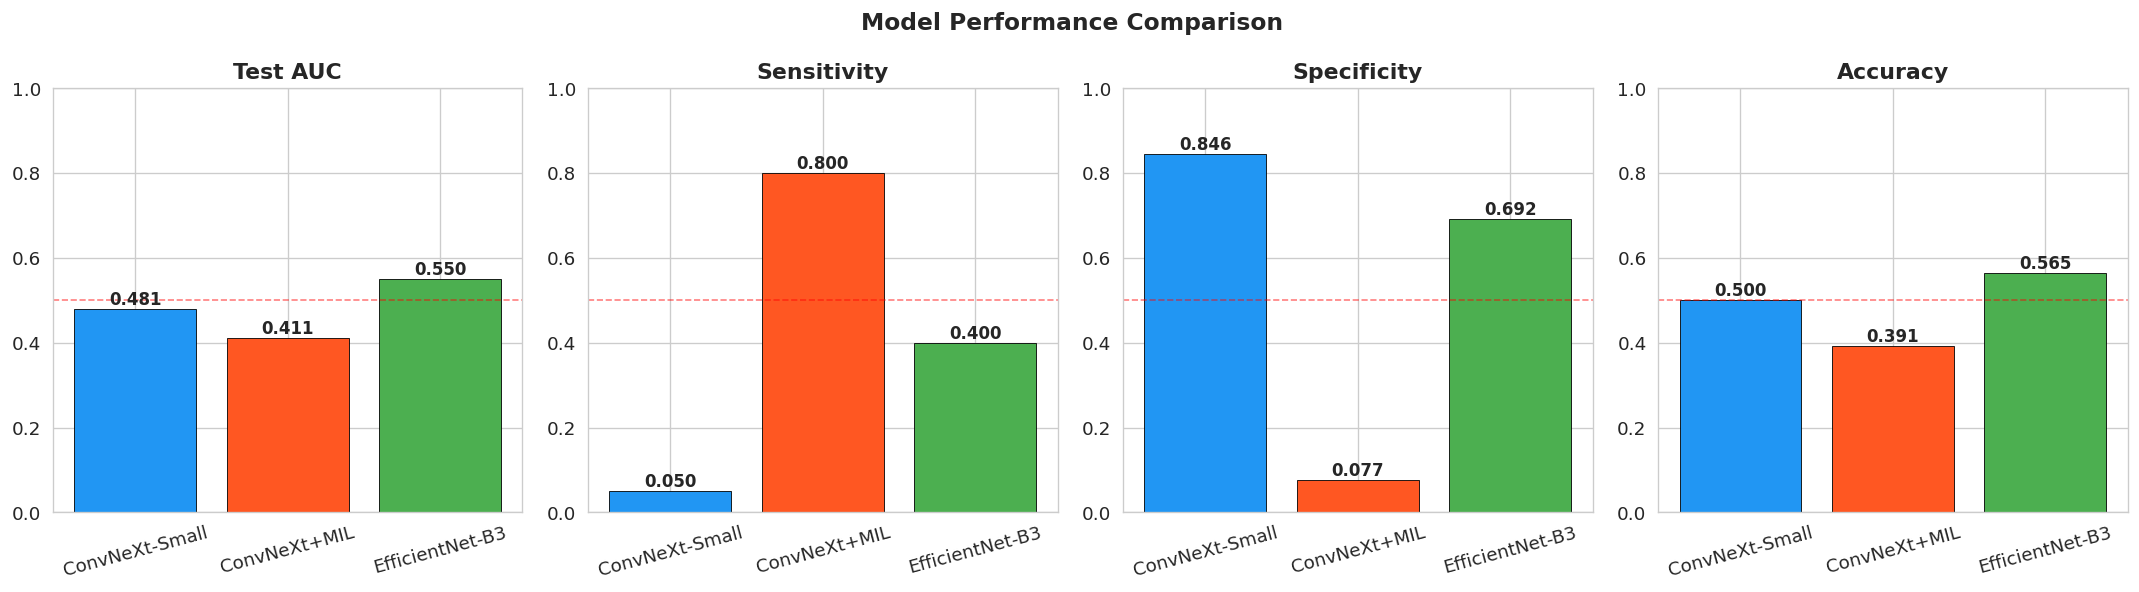

In [14]:
# Cell 14 — Visual comparison bar chart
metrics   = ['Test AUC', 'Sensitivity', 'Specificity', 'Accuracy']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    vals   = [summary_df.loc[summary_df['Model'] == name, metric].values[0]
              for name in model_predictions.keys()]
    names  = list(model_predictions.keys())
    bars   = ax.bar(names, vals, color=colors[:len(names)],
                    edgecolor='black', linewidth=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
               f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eval_comparison.png', bbox_inches='tight')
plt.show()

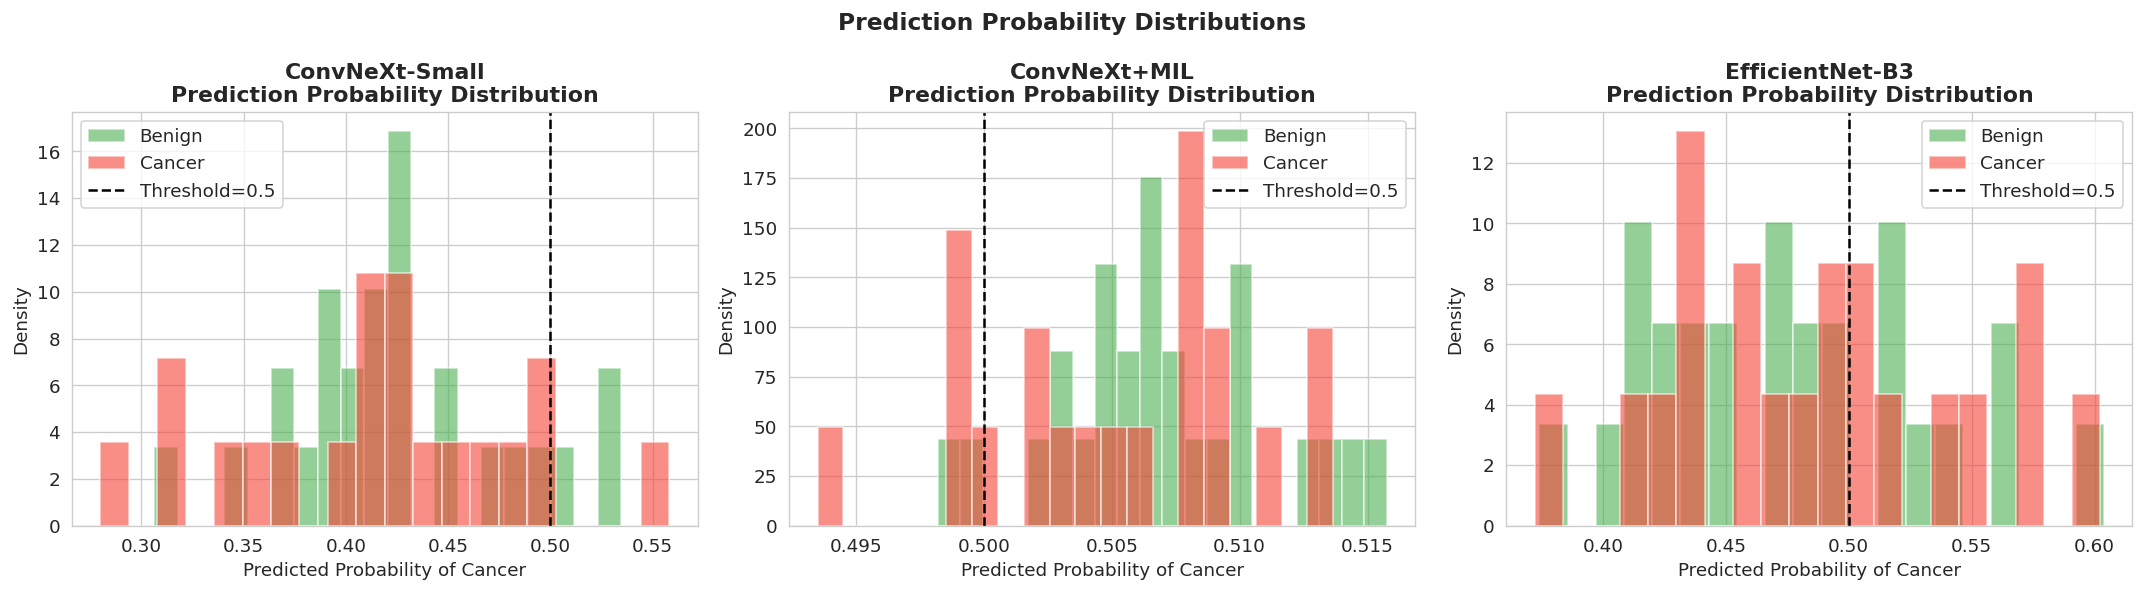

In [15]:
# Cell 15 — Probability distribution plots
fig, axes = plt.subplots(1, len(model_predictions), figsize=(6 * len(model_predictions), 5))
if len(model_predictions) == 1:
    axes = [axes]

for ax, (name, data) in zip(axes, model_predictions.items()):
    benign_probs = data['probs'][data['labels'] == 0]
    cancer_probs = data['probs'][data['labels'] == 1]
    ax.hist(benign_probs, bins=20, alpha=0.6, color='#4CAF50', label='Benign', density=True)
    ax.hist(cancer_probs, bins=20, alpha=0.6, color='#F44336', label='Cancer', density=True)
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold=0.5')
    ax.set_title(f'{name}\nPrediction Probability Distribution', fontweight='bold')
    ax.set_xlabel('Predicted Probability of Cancer')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Prediction Probability Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/eval_prob_distributions.png', bbox_inches='tight')
plt.show()

=== ENSEMBLE RESULTS (Average of all models) ===
Test AUC:          0.4923
Average Precision: 0.5047

              precision    recall  f1-score   support

      Benign     0.5789    0.8462    0.6875        26
      Cancer     0.5000    0.2000    0.2857        20

    accuracy                         0.5652        46
   macro avg     0.5395    0.5231    0.4866        46
weighted avg     0.5446    0.5652    0.5128        46



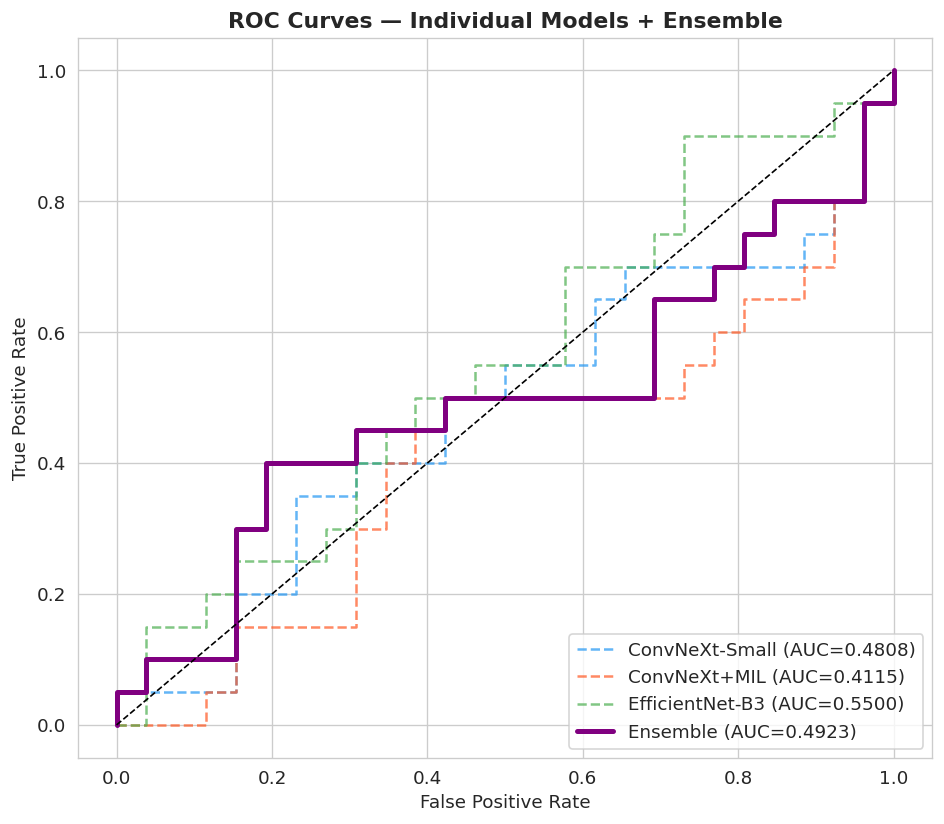

In [16]:
# Cell 16 — Ensemble prediction (average all models)
if len(model_predictions) > 1:
    # Average probabilities across all models
    all_model_probs = np.stack([data['probs'] for data in model_predictions.values()])
    ensemble_probs  = all_model_probs.mean(axis=0)
    ensemble_preds  = (ensemble_probs > 0.5).astype(float)
    ensemble_labels = list(model_predictions.values())[0]['labels']

    ensemble_auc = roc_auc_score(ensemble_labels, ensemble_probs)
    ensemble_ap  = average_precision_score(ensemble_labels, ensemble_probs)

    print('=== ENSEMBLE RESULTS (Average of all models) ===')
    print(f'Test AUC:          {ensemble_auc:.4f}')
    print(f'Average Precision: {ensemble_ap:.4f}')
    print()
    print(classification_report(
        ensemble_labels, ensemble_preds,
        target_names=['Benign', 'Cancer'], digits=4
    ))

    # Add ensemble to ROC plot
    plt.figure(figsize=(8, 7))
    for (name, data), color in zip(model_predictions.items(), colors):
        fpr, tpr, _ = roc_curve(data['labels'], data['probs'])
        auc = roc_auc_score(data['labels'], data['probs'])
        plt.plot(fpr, tpr, color=color, linewidth=1.5,
                 linestyle='--', label=f'{name} (AUC={auc:.4f})', alpha=0.7)

    fpr_ens, tpr_ens, _ = roc_curve(ensemble_labels, ensemble_probs)
    plt.plot(fpr_ens, tpr_ens, color='purple', linewidth=3,
             label=f'Ensemble (AUC={ensemble_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves — Individual Models + Ensemble', fontweight='bold')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(f'{DATA_DIR}/eval_roc_with_ensemble.png', bbox_inches='tight')
    plt.show()
else:
    print('Need at least 2 models for ensemble.')

In [18]:
# Cell 17 — Final summary printout
print('=' * 65)
print('  FINAL RESULTS SUMMARY — fastMRI Prostate Cancer Classification')
print('=' * 65)
print(f'  Dataset:    fastMRI Prostate, NYU (312 patients, T2 MRI)')
print(f'  Task:       Binary PIRADS classification (≥3 = cancer)')
print(f'  Test set:   {len(test_df)} patients ({test_df.binary_label.sum()} cancer, {(test_df.binary_label==0).sum()} benign)')
print(f'  Input:      3x3 grid of middle 9 T2 slices (224x224)')
print(f'  Tuning:     Optuna (20 trials, TPE + MedianPruner)')
print()
print(f'  {"Model":<20} {"Val AUC":>10} {"Test AUC":>10} {"Sensitivity":>13} {"Specificity":>13}')
print('  ' + '-' * 68)
for _, row in summary_df.iterrows():
    val_auc = results.get(row["Model"].split("+")[0].strip(), {}).get('best_val_auc', 'N/A')
    val_str = f'{val_auc:.4f}' if isinstance(val_auc, float) else val_auc
    print(f'  {row["Model"]:<20} {val_str:>10} {row["Test AUC"]:>10.4f} {row["Sensitivity"]:>13.4f} {row["Specificity"]:>13.4f}')

if len(model_predictions) > 1:
    print(f'  {"Ensemble":<20} {"":>10} {ensemble_auc:>10.4f}')

print()
print('  Baseline comparison:')
print(f'    Random classifier:           Test AUC = 0.5000')
print('=' * 65)

  FINAL RESULTS SUMMARY — fastMRI Prostate Cancer Classification
  Dataset:    fastMRI Prostate, NYU (312 patients, T2 MRI)
  Task:       Binary PIRADS classification (≥3 = cancer)
  Test set:   46 patients (20 cancer, 26 benign)
  Input:      3x3 grid of middle 9 T2 slices (224x224)
  Tuning:     Optuna (20 trials, TPE + MedianPruner)

  Model                   Val AUC   Test AUC   Sensitivity   Specificity
  --------------------------------------------------------------------
  ConvNeXt-Small              N/A     0.4808        0.0500        0.8462
  ConvNeXt+MIL             0.5303     0.4115        0.8000        0.0769
  EfficientNet-B3             N/A     0.5500        0.4000        0.6923
  Ensemble                            0.4923

  Baseline comparison:
    Random classifier:           Test AUC = 0.5000
